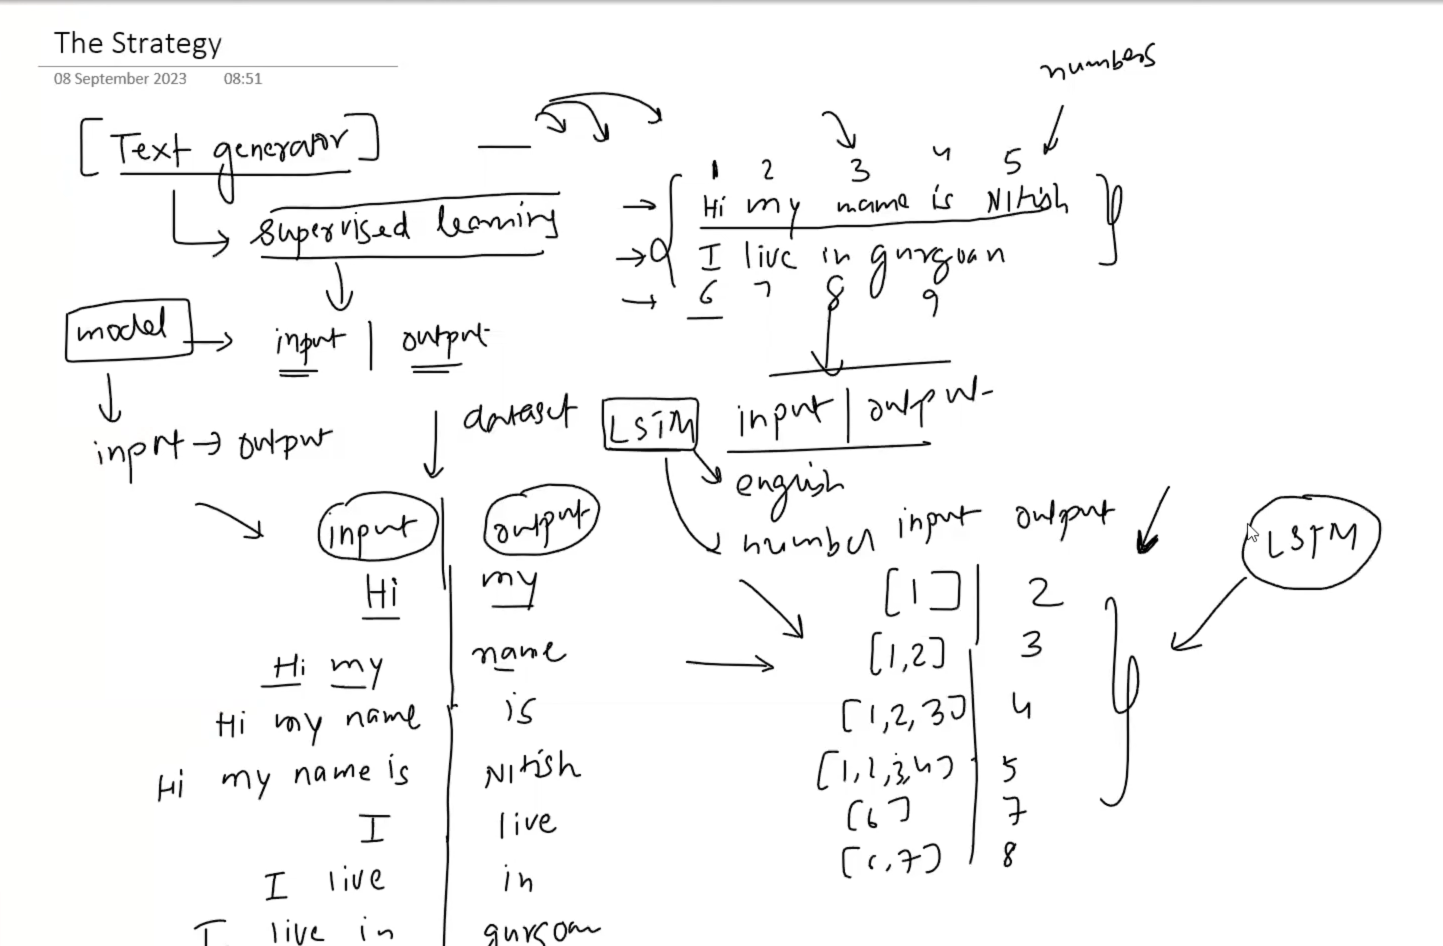

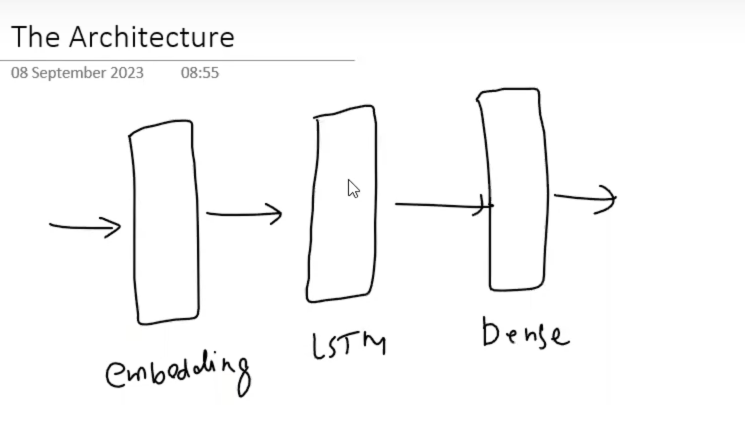

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [21]:
text = """
Hi my name is Ayush
I live in Haryana
I am a ML Engineer
I love machine learning,AI
"""

In [22]:
sentences = [line.strip() for line in text.split('\n') if line.strip()]
print("Sentences:", sentences)

Sentences: ['Hi my name is Ayush', 'I live in Haryana', 'I am a ML Engineer', 'I love machine learning,AI']


 # Tokenize Words → Numbers

In [23]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(sentences)

sequences = tokenizer.texts_to_sequences(sentences)
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size:", vocab_size)
print("Word Index:", tokenizer.word_index)

Vocabulary Size: 19
Word Index: {'<OOV>': 1, 'i': 2, 'hi': 3, 'my': 4, 'name': 5, 'is': 6, 'ayush': 7, 'live': 8, 'in': 9, 'haryana': 10, 'am': 11, 'a': 12, 'ml': 13, 'engineer': 14, 'love': 15, 'machine': 16, 'learning': 17, 'ai': 18}


# Create Input-Output Pairs

In [24]:
input_sequences = []
output_labels = []

for seq in sequences:
    for i in range(1, len(seq)):
        input_seq = seq[:i]
        output_label = seq[i]
        input_sequences.append(input_seq)
        output_labels.append(output_label)

max_length = max([len(x) for x in input_sequences])
input_sequences = pad_sequences(input_sequences, maxlen=max_length, padding='pre')
output_labels = np.array(output_labels)

# Build Model

In [25]:
model = Sequential([
    # 🟦 1. Embedding Layer
    Embedding(
        input_dim=vocab_size,
        output_dim=10,           # embedding dimension
        input_length=max_length  # length of input sequences
    ),

    # 🟨 2. LSTM Layer
    LSTM(
        units=50,               # number of memory cells
        return_sequences=False  # only last output
    ),

    # 🟩 3. Dense Layer (Classification)
    Dense(
        units=vocab_size,
        activation='softmax'    # multi-class probability distribution
    )
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    input_sequences,
    output_labels,
    epochs=300,
    verbose=1,
    batch_size=8
)

Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.0000e+00 - loss: 2.9452
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0889 - loss: 2.9428    
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2583 - loss: 2.9398
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1722 - loss: 2.9384
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1306 - loss: 2.9369
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1750 - loss: 2.9351
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2583 - loss: 2.9330
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1750 - loss: 2.9320
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2583 - loss: 2.9263
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1333 - loss: 2.9281    
Epoch 11/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2167 - loss: 2.9238
Epoch 12/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy:

In [27]:
def predict_next_word(model, tokenizer, sentence, max_length):
    tokens = tokenizer.texts_to_sequences([sentence])[0]
    padded = pad_sequences([tokens], maxlen=max_length, padding='pre')
    prediction = model.predict(padded, verbose=0)
    predicted_index = np.argmax(prediction[0])
    predicted_word = tokenizer.index_word.get(predicted_index, "<OOV>")
    return predicted_word

# Test
test_sentence = "Hi my"
next_word = predict_next_word(model, tokenizer, test_sentence, max_length)
print(f"Next word after '{test_sentence}': {next_word}")

Next word after 'Hi my': name



---

### 🔁 Model Recap (From Earlier Code)

```python
model = Sequential([
    Embedding(vocab_size, 10, input_length=max_length),
    LSTM(50),
    Dense(vocab_size, activation='softmax')
])
```

Assume:
- `vocab_size = 12` (from your sample text)
- `max_length = 4` (longest input sequence)
- `embedding_dim = 10`
- `lstm_units = 50`

---

## ✅ Step 1: **Embedding Layer Parameters**

```python
Embedding(input_dim=vocab_size, output_dim=10, input_length=max_length)
```

- Input: word indices (size: `vocab_size = 12`)
- Output: dense vectors of size 10

Each word gets a vector → total vectors = `vocab_size`

> 🔢 **Parameters = vocab_size × embedding_dim**

$$
12 \times 10 = \boxed{120}
$$

✅ These are the **embedding weights**: one 10D vector per word.

> ❗ Note: `input_length` (sequence length) does **not** affect parameter count.

---

## ✅ Step 2: **LSTM Layer Parameters**

```python
LSTM(units=50)
```

An LSTM has **four gates**:  
Forget, Input, Candidate (Cell), Output — each uses a linear transformation.

For each gate:
- Weight matrix: from input + hidden state → 50 units

Let:
- `input_dim = embedding_dim = 10`
- `hidden_dim = 50`

So:
- Input-to-hidden weight: `10 × 50 = 500`
- Hidden-to-hidden (recurrent) weight: `50 × 50 = 2500`
- Bias: `50`

Total per gate: $ 500 + 2500 + 50 = 3050 $

But there are **4 gates**, so:

$$
4 \times (input\_dim + hidden\_dim + 1) \times hidden\_dim
$$

$$
= 4 \times (10 + 50 + 1) \times 50 = 4 \times 61 \times 50 = \boxed{12,200}
$$

> ✅ Formula:
> $$
> \text{LSTM Params} = 4 \times (n_{in} + n_{out} + 1) \times n_{out}
> $$

Where:
- $ n_{in} = 10 $ (embedding output size)
- $ n_{out} = 50 $ (number of LSTM units)

---

## ✅ Step 3: **Dense (Output) Layer Parameters**

```python
Dense(vocab_size, activation='softmax')
```

- Input: from LSTM → size 50
- Output: one score per word → size = `vocab_size = 12`

So:
- Weight matrix: $ 50 \times 12 = 600 $
- Bias: $ 12 $

$$
(50 \times 12) + 12 = 600 + 12 = \boxed{612}
$$

---

## 🧮 Total Trainable Parameters

| Layer | Parameters |
|------|------------|
| Embedding | 120 |
| LSTM | 12,200 |
| Dense | 612 |
| **Total** | **12,932** |

$$
\boxed{12,932} \text{ trainable parameters}
$$

---

## 🔍 Verification with Keras

You can always verify this in code:

```python
model.summary()
```

Output will show:
```
Layer (type)                 Output Shape              Param #
=================================================================
embedding (Embedding)        (None, 4, 10)               120
lstm (LSTM)                  (None, 50)                  12200
dense (Dense)                (None, 12)                  612
=================================================================
Total params: 12,932
Trainable params: 12,932
Non-trainable params: 0
```

✅ Matches perfectly!

---

## 📌 Summary Table

| Layer | Input Size | Output Size | Parameter Formula | Count |
|------|------------|-------------|-------------------|-------|
| **Embedding** | 12 words | 10-dim vectors | `vocab_size × embedding_dim` | 120 |
| **LSTM** | 10 | 50 | `4 × (10 + 50 + 1) × 50` | 12,200 |
| **Dense** | 50 | 12 classes | `(50 × 12) + 12` | 612 |
| **Total** | — | — | — | **12,932** |

---




---

## ✅ 1. **Use More & Better Training Data**

### 🔧 Why?
More diverse sentences help the model learn real language patterns.

### 💡 How:
```python
text = """
Hi my name is Ayush
I live in Gurgaon
I am a data scientist
I love machine learning
Machine learning is powerful
Data science combines statistics and coding
...
"""
```
> Use real text: books, articles, tweets, etc.

✅ Larger vocabulary → better generalization.

---

## ✅ 2. **Increase Sequence Length (Context Window)**

### 🔧 Why?
Longer input sequences give more context (e.g., “I love machine” → “learning”).

### 💡 How:
Ensure `max_length` captures full meaningful context:
```python
max_length = 5  # instead of 3 or 4
```

Also consider using **sliding windows** over longer texts:
```python
# From: "I love machine learning very much"
# Create:
# ["I"] → "love"
# ["I", "love"] → "machine"
# ...
# ["machine", "learning", "very"] → "much"
```

---

## ✅ 3. **Use Pretrained Embeddings (e.g., Word2Vec, GloVe)**

### 🔧 Why?
Random embeddings start from scratch. Pretrained ones already know word meanings.

### 💡 How:
Replace random embedding with pretrained vectors:
```python
# Example: Load GloVe vectors
embeddings_index = {}
with open('glove.6B.50d.txt') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Build embedding matrix
embedding_matrix = np.zeros((vocab_size, 50))
for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Use in model
model.add(Embedding(vocab_size, 50, weights=[embedding_matrix],
                    input_length=max_length, trainable=False))
```

✅ Helps even with small datasets.

---

## ✅ 4. **Stack Multiple LSTMs (Deeper Network)**

### 🔧 Why?
Single LSTM may not capture complex patterns. Stacked LSTMs learn hierarchical features.

### 💡 How:
```python
model = Sequential([
    Embedding(vocab_size, 100, input_length=max_length),
    LSTM(128, return_sequences=True),  # Keep output for next LSTM
    LSTM(128, return_sequences=False),
    Dense(vocab_size, activation='softmax')
])
```

> First LSTM returns full sequence (`return_sequences=True`) so second can process it.

✅ Deeper networks = more expressive power.

---

## ✅ 5. **Add Dropout for Regularization**

### 🔧 Why?
Prevents overfitting by randomly disabling neurons during training.

### 💡 How:
```python
from tensorflow.keras.layers import Dropout

model = Sequential([
    Embedding(vocab_size, 100, input_length=max_length),
    LSTM(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.3),
    Dense(vocab_size, activation='softmax')
])
```

Or add after Dense:
```python
Dense(128, activation='relu'),
Dropout(0.5),
Dense(vocab_size, activation='softmax')
```

✅ Reduces overfitting → better generalization.

---

## ✅ 6. **Use Bidirectional LSTM**

### 🔧 Why?
Standard LSTM only sees past context. Bidirectional sees **past + future** (great for context!).

### 💡 How:
```python
from tensorflow.keras.layers import Bidirectional

model = Sequential([
    Embedding(vocab_size, 100, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(vocab_size, activation='softmax')
])
```

> Doubles parameters but improves accuracy.

✅ Especially useful in NLP tasks like translation, tagging, prediction.

---

## ✅ 7. **Tune Hyperparameters**

### 🔧 Key Parameters to Tune:
| Parameter | Suggestion |
|--------|-----------|
| `embedding_dim` | Try 50, 100, 200 |
| `lstm_units` | Try 64, 128, 256 |
| `learning_rate` | Use `Adam(learning_rate=0.001)` or lower |
| `batch_size` | 16, 32, 64 |
| `epochs` | Use early stopping instead of fixed epochs |

### 💡 Example with Early Stopping:
```python
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

model.fit(X, y, epochs=500, callbacks=[early_stop])
```

---

## ✅ 8. **Use Character-Level or Subword Tokenization (Optional)**

### 🔧 Why?
Word-level fails on unknown words. Character/subword models handle OOV better.

### 💡 Options:
- **Character-level**: Predict one character at a time.
- **Byte Pair Encoding (BPE)**: Used in GPT, BERT.
- **SentencePiece / Subword Tokenizer**: Available in `tensorflow-text`.

✅ More robust, especially for rare words.

---

## ✅ 9. **Generate Sequences with Sampling (Not Just Argmax)**

### 🔧 Why?
Always picking the highest-probability word leads to repetitive outputs.

### 💡 Improve Generation:
Use **softmax sampling** or **top-k sampling**:
```python
import random

def sample_word(predictions, temperature=1.0):
    predictions = np.log(predictions + 1e-8) / temperature
    exp_preds = np.exp(predictions)
    probs = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(probs), p=probs)
```

> Higher `temperature` → more creative; lower → more conservative.

---

## ✅ 10. **Switch to Modern Architectures (Long-Term Upgrade)**

While LSTMs are great for learning, newer models outperform them:

| Model | Advantage |
|------|----------|
| **Transformer (e.g., GPT-style)** | Better at long-range dependencies |
| **BERT-style masked LM** | Uses bidirectional context |
| **Tiny models (DistilGPT, ALBERT)** | Fast, small, accurate |

But for now, stick with LSTM — it's perfect for learning!

---

## 📊 Quick Comparison: Before vs After Optimization

| Feature | Basic Model | Improved Model |
|-------|-------------|----------------|
| Data | Small hand-written | Large real-world |
| Embedding | Random | Pretrained (GloVe) |
| Layers | 1 LSTM | Stacked or Bidirectional |
| Dropout | No | Yes (0.3–0.5) |
| Context | Short | Longer sequences |
| Output | Argmax | Sampling |
| Performance | Low accuracy | High accuracy & fluency |

---

